# 🧠 Notebook 0: LLM Fundamentals

**Based on Lectures 1-4 from Vizuara AI Series**

---

## 🎯 Learning Objectives

By the end of this notebook, you will understand:

1. **What is an LLM?** - The fundamental task of next-token prediction
2. **Why Transformers?** - Evolution from RNNs to Transformers
3. **Encoder vs Decoder** - Different architectures for different tasks
4. **Why GPT is Decoder-only** - Design choices for text generation

---

## 📚 Table of Contents

1. [What is an LLM?](#1-what-is-an-llm)
2. [Next-Token Prediction](#2-next-token-prediction)
3. [Evolution: RNN → Transformer](#3-evolution-rnn-to-transformer)
4. [Encoder vs Decoder Architecture](#4-encoder-vs-decoder-architecture)
5. [Why GPT is Decoder-Only](#5-why-gpt-is-decoder-only)
6. [Key Takeaways](#6-key-takeaways)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import sys

# Add src to path for imports
# sys.path.append('../src')
# from visualization import create_pipeline_diagram   # ← comment out

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Ensure output directories exist
os.makedirs('../visualizations', exist_ok=True)
os.makedirs('../src', exist_ok=True)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---

## 1. What is an LLM?

### 🧠 Intuition

A **Large Language Model (LLM)** is not a magic box that "understands" language. Instead, it's a sophisticated **statistical pattern recognizer** trained on massive amounts of text.

Think of it like this:
- You've read millions of books
- Someone says: "The cat sat on the..."
- Your brain automatically thinks: "mat" (most likely), "floor" (likely), "moon" (very unlikely)

That's exactly what an LLM does—it calculates probabilities!

### 📊 The Core Task: Next-Token Prediction

An LLM's **only job** during training is:

```
Given: "The cat sat on the"
Predict: What comes next?
```

It doesn't retrieve answers from a database. It **generates** text by predicting one token at a time.

### 🔍 Key Characteristics

1. **Large**: Billions of parameters (weights)
2. **Language**: Trained on text data
3. **Model**: A mathematical function that maps input → output

**GPT-3**: 175 billion parameters  
**GPT-4**: Estimated 1+ trillion parameters

---

## 2. Next-Token Prediction

### 📐 Mathematical Formulation

Given a sequence of tokens $x_1, x_2, ..., x_t$, the model computes:

$$P(x_{t+1} | x_1, x_2, ..., x_t)$$

This is a **probability distribution** over all possible next tokens.

### 💻 Visualization: Probability Distribution

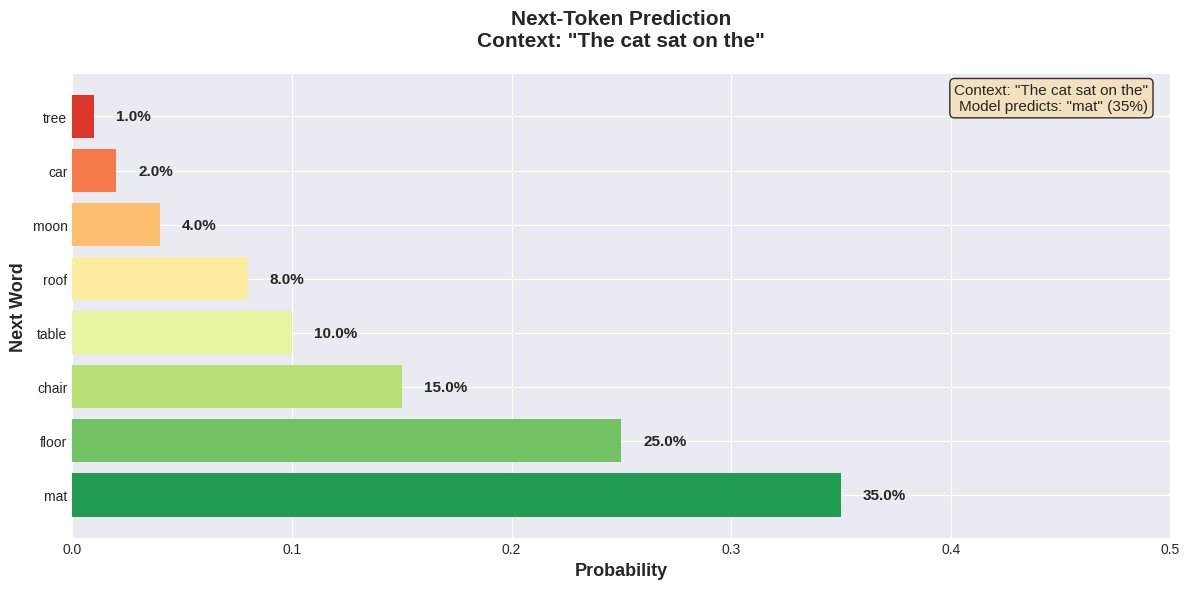


📊 Key Insight:
The model assigns highest probability to 'mat' (35%) because it has seen
this pattern millions of times in training data.

Note: These are simulated probabilities for illustration.


In [7]:
# Simulate next-token prediction probabilities
context = "The cat sat on the"

# Simulated probabilities for different next words
next_words = ['mat', 'floor', 'chair', 'table', 'roof', 'moon', 'car', 'tree']
probabilities = [0.35, 0.25, 0.15, 0.10, 0.08, 0.04, 0.02, 0.01]

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette("RdYlGn_r", len(next_words))
bars = ax.barh(next_words, probabilities, color=colors)

# Add percentage labels
for i, (bar, prob) in enumerate(zip(bars, probabilities)):
    ax.text(prob + 0.01, i, f'{prob*100:.1f}%', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Probability', fontsize=13, fontweight='bold')
ax.set_ylabel('Next Word', fontsize=13, fontweight='bold')
ax.set_title(f'Next-Token Prediction\nContext: "{context}"', fontsize=15, fontweight='bold', pad=20)
ax.set_xlim(0, 0.5)

# Add context box
ax.text(0.98, 0.98, f'Context: "{context}"\nModel predicts: "{next_words[0]}" (35%)', 
        transform=ax.transAxes, fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../visualizations/next_token_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Key Insight:")
print("The model assigns highest probability to 'mat' (35%) because it has seen")
print("this pattern millions of times in training data.")
print("\nNote: These are simulated probabilities for illustration.")

### 🎲 Sampling Strategies

The model doesn't always pick the highest probability word. It can:

1. **Greedy Sampling**: Always pick the most likely token (deterministic)
2. **Temperature Sampling**: Add randomness (creative but less coherent)
3. **Top-k Sampling**: Sample from top k most likely tokens
4. **Top-p (Nucleus) Sampling**: Sample from smallest set with cumulative probability ≥ p

This is why ChatGPT gives different responses to the same prompt!

---

## 3. Evolution: RNN → Transformer

### 📜 The Old Way: Recurrent Neural Networks (RNNs)

**Before 2017**, language models used RNNs/LSTMs:

```
Input:  "The cat sat on the mat"
Process: The → cat → sat → on → the → mat (sequential)
```

#### ❌ Problems with RNNs:

1. **Sequential Processing**: Must process word-by-word (slow)
2. **Vanishing Gradients**: Forgets information from beginning of long sentences
3. **No Parallelization**: Can't use GPU efficiently

### ⚡ The New Way: Transformers (2017)

**"Attention Is All You Need"** paper introduced Transformers:

```
Input:  "The cat sat on the mat"
Process: [The, cat, sat, on, the, mat] (all at once!)
```

#### ✅ Advantages of Transformers:

1. **Parallel Processing**: Process entire sequence simultaneously
2. **Attention Mechanism**: Every word can "look at" every other word
3. **Long-Range Dependencies**: No forgetting problem
4. **Scalability**: Can train on massive datasets efficiently

/tmp/ipython-input-288/2852136544.py:48: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-288/2852136544.py:48: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-288/2852136544.py:49: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.savefig('../visualizations/rnn_vs_transformer.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-288/2852136544.py:49: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig('../visualizations/rnn_vs_transformer.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarnin

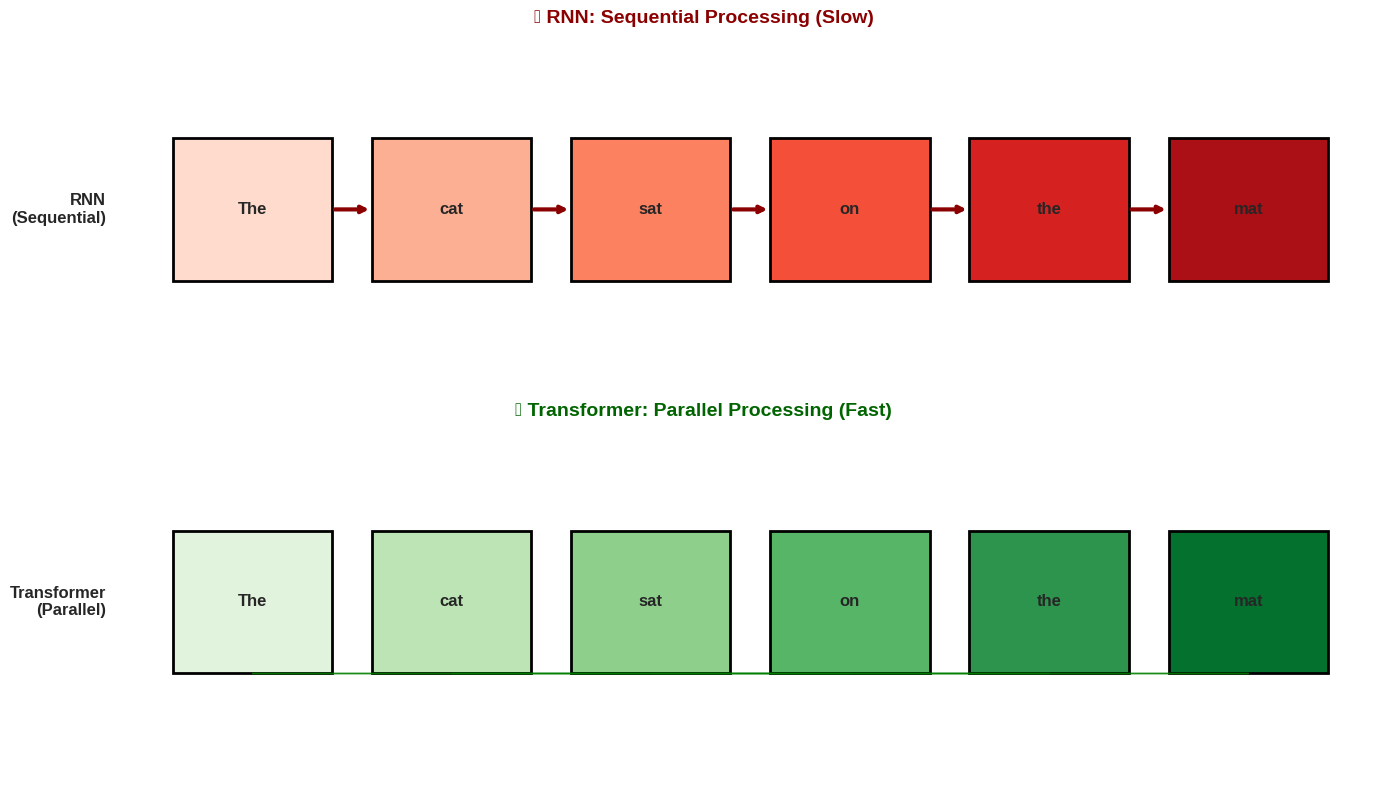


⚡ Speed Comparison:
RNN:         Process 1 word at a time → 6 sequential steps
Transformer: Process all 6 words at once → 1 parallel step

Result: Transformers are ~100x faster to train!


In [8]:
# Visualization: Sequential vs Parallel Processing
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

words = ['The', 'cat', 'sat', 'on', 'the', 'mat']
n_words = len(words)

# RNN: Sequential Processing
ax = axes[0]
colors_rnn = sns.color_palette("Reds", n_words)

for i, (word, color) in enumerate(zip(words, colors_rnn)):
    rect = plt.Rectangle((i*1.5, 0.3), 1.2, 0.4, facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(i*1.5 + 0.6, 0.5, word, ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Add arrows
    if i < n_words - 1:
        ax.annotate('', xy=((i+1)*1.5, 0.5), xytext=(i*1.5 + 1.2, 0.5),
                   arrowprops=dict(arrowstyle='->', lw=3, color='darkred'))

ax.text(-0.5, 0.5, 'RNN\n(Sequential)', ha='right', va='center', fontsize=12, fontweight='bold')
ax.set_xlim(-1, n_words*1.5)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('❌ RNN: Sequential Processing (Slow)', fontsize=14, fontweight='bold', color='darkred')

# Transformer: Parallel Processing
ax = axes[1]
colors_transformer = sns.color_palette("Greens", n_words)

for i, (word, color) in enumerate(zip(words, colors_transformer)):
    rect = plt.Rectangle((i*1.5, 0.3), 1.2, 0.4, facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(i*1.5 + 0.6, 0.5, word, ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Add bidirectional connections (attention)
    for j in range(n_words):
        if i != j:
            ax.plot([i*1.5 + 0.6, j*1.5 + 0.6], [0.3, 0.3], 
                   'g-', alpha=0.2, linewidth=1)

ax.text(-0.5, 0.5, 'Transformer\n(Parallel)', ha='right', va='center', fontsize=12, fontweight='bold')
ax.set_xlim(-1, n_words*1.5)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('✅ Transformer: Parallel Processing (Fast)', fontsize=14, fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.savefig('../visualizations/rnn_vs_transformer.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n⚡ Speed Comparison:")
print("RNN:         Process 1 word at a time → 6 sequential steps")
print("Transformer: Process all 6 words at once → 1 parallel step")
print("\nResult: Transformers are ~100x faster to train!")

---

## 4. Encoder vs Decoder Architecture

### 🏗️ The Original Transformer (2017)

The original "Attention Is All You Need" paper had **two parts**:

1. **Encoder**: Reads and understands the input
2. **Decoder**: Generates the output

This was designed for **translation** (English → French).

### 📖 Encoder: The "Reader"

**Purpose**: Understand the input text

**Key Feature**: **Bidirectional** attention
- Can look at words before AND after the current word
- Example: To understand "bank" in "I went to the bank to deposit money", it looks at "deposit" (comes after)

**Use Cases**:
- Text classification (spam detection)
- Sentiment analysis
- Question answering
- Named entity recognition

**Famous Model**: BERT (Bidirectional Encoder Representations from Transformers)

### ✍️ Decoder: The "Writer"

**Purpose**: Generate new text

**Key Feature**: **Unidirectional** (causal) attention
- Can ONLY look at words that came before
- Cannot "peek" at future words (that would be cheating!)

**Use Cases**:
- Text generation
- Chatbots
- Code completion
- Story writing

**Famous Model**: GPT (Generative Pre-trained Transformer)

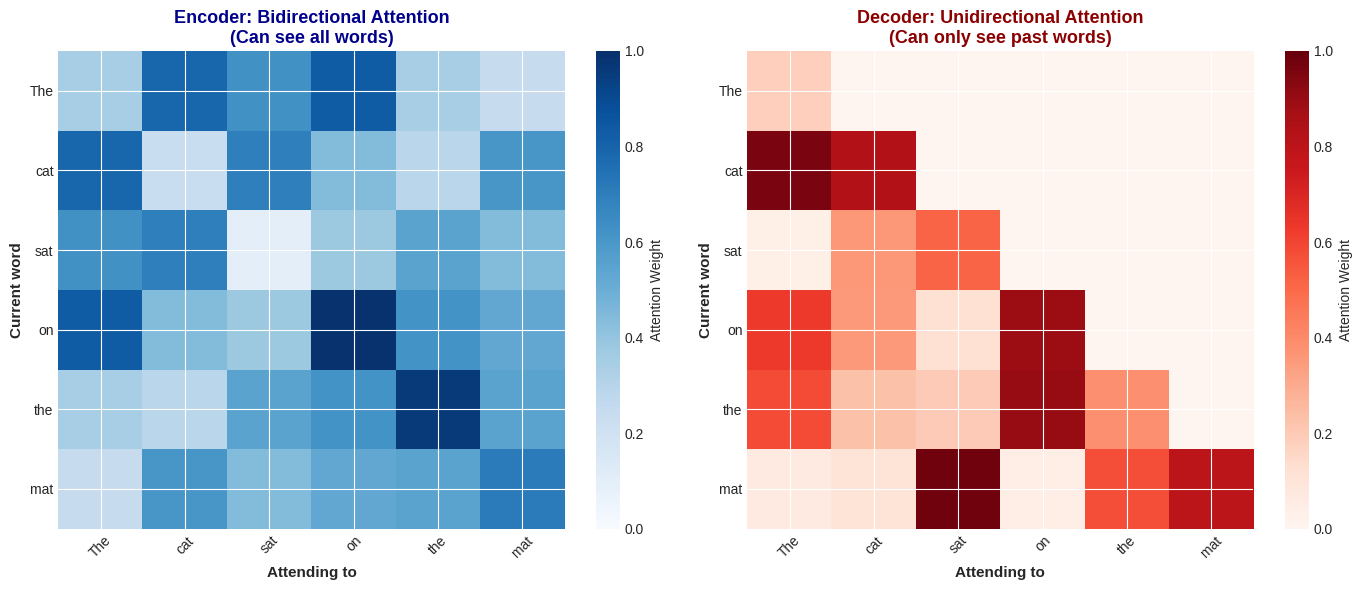


🔍 Key Difference:
Encoder: Full matrix (can attend to all positions)
Decoder: Lower triangular (can only attend to previous positions)

The white area in Decoder = 'future' that the model cannot see!


In [9]:
# Visualization: Encoder vs Decoder Attention Patterns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Create attention matrices
seq_len = 6
words = ['The', 'cat', 'sat', 'on', 'the', 'mat']

# Encoder: Bidirectional (full matrix)
encoder_attention = np.random.rand(seq_len, seq_len)
encoder_attention = (encoder_attention + encoder_attention.T) / 2  # Make symmetric

im1 = axes[0].imshow(encoder_attention, cmap='Blues', aspect='auto', vmin=0, vmax=1)
axes[0].set_xticks(range(seq_len))
axes[0].set_yticks(range(seq_len))
axes[0].set_xticklabels(words, rotation=45)
axes[0].set_yticklabels(words)
axes[0].set_xlabel('Attending to', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Current word', fontsize=11, fontweight='bold')
axes[0].set_title('Encoder: Bidirectional Attention\n(Can see all words)', 
                 fontsize=13, fontweight='bold', color='darkblue')
plt.colorbar(im1, ax=axes[0], label='Attention Weight')

# Decoder: Unidirectional (lower triangular)
decoder_attention = np.tril(np.random.rand(seq_len, seq_len))

im2 = axes[1].imshow(decoder_attention, cmap='Reds', aspect='auto', vmin=0, vmax=1)
axes[1].set_xticks(range(seq_len))
axes[1].set_yticks(range(seq_len))
axes[1].set_xticklabels(words, rotation=45)
axes[1].set_yticklabels(words)
axes[1].set_xlabel('Attending to', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Current word', fontsize=11, fontweight='bold')
axes[1].set_title('Decoder: Unidirectional Attention\n(Can only see past words)', 
                 fontsize=13, fontweight='bold', color='darkred')
plt.colorbar(im2, ax=axes[1], label='Attention Weight')

plt.tight_layout()
plt.savefig('../visualizations/encoder_vs_decoder_attention.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🔍 Key Difference:")
print("Encoder: Full matrix (can attend to all positions)")
print("Decoder: Lower triangular (can only attend to previous positions)")
print("\nThe white area in Decoder = 'future' that the model cannot see!")

### 📊 Comparison Table

| Feature | Encoder | Decoder |
|---------|---------|----------|
| **Attention** | Bidirectional | Unidirectional (Causal) |
| **Can see future?** | ✅ Yes | ❌ No |
| **Task** | Understanding | Generation |
| **Example Model** | BERT | GPT |
| **Use Case** | Classification, Q&A | Text generation, Chat |
| **Training** | Masked Language Modeling | Next-token prediction |

### 🔄 Full Transformer (Encoder + Decoder)

Some models use **both**:
- **T5** (Text-to-Text Transfer Transformer)
- **BART** (Bidirectional and Auto-Regressive Transformers)

Use case: Translation, Summarization

---

## 5. Why GPT is Decoder-Only

### 🎯 Design Philosophy

GPT (Generative Pre-trained Transformer) is **Decoder-only** because:

1. **Goal**: Generate text (not understand/classify)
2. **Causal Constraint**: Must predict next token without seeing the future
3. **Simplicity**: Simpler architecture = easier to scale
4. **Efficiency**: Don't need bidirectional attention for generation

### 🔒 The Causal Mask

The key innovation is the **causal mask** (also called attention mask):

```python
# Attention mask (lower triangular matrix)
[[1, 0, 0, 0],   # Token 1 can only see itself
 [1, 1, 0, 0],   # Token 2 can see tokens 1-2
 [1, 1, 1, 0],   # Token 3 can see tokens 1-3
 [1, 1, 1, 1]]   # Token 4 can see all tokens
```

This ensures the model **never cheats** by looking at future tokens during training.

### 🚀 Why This Works

During training:
```
Input:  "The cat sat on"
Target: "cat sat on the"
```

The model learns:
- Given "The" → predict "cat"
- Given "The cat" → predict "sat"
- Given "The cat sat" → predict "on"
- Given "The cat sat on" → predict "the"

**All in one forward pass!** (Thanks to parallel processing)

/tmp/ipython-input-288/1782261159.py:44: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-288/1782261159.py:44: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-288/1782261159.py:45: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig('../visualizations/causal_mask.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-288/1782261159.py:45: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.savefig('../visualizations/causal_mask.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10007 (\N{BALLOT X}) missing fr

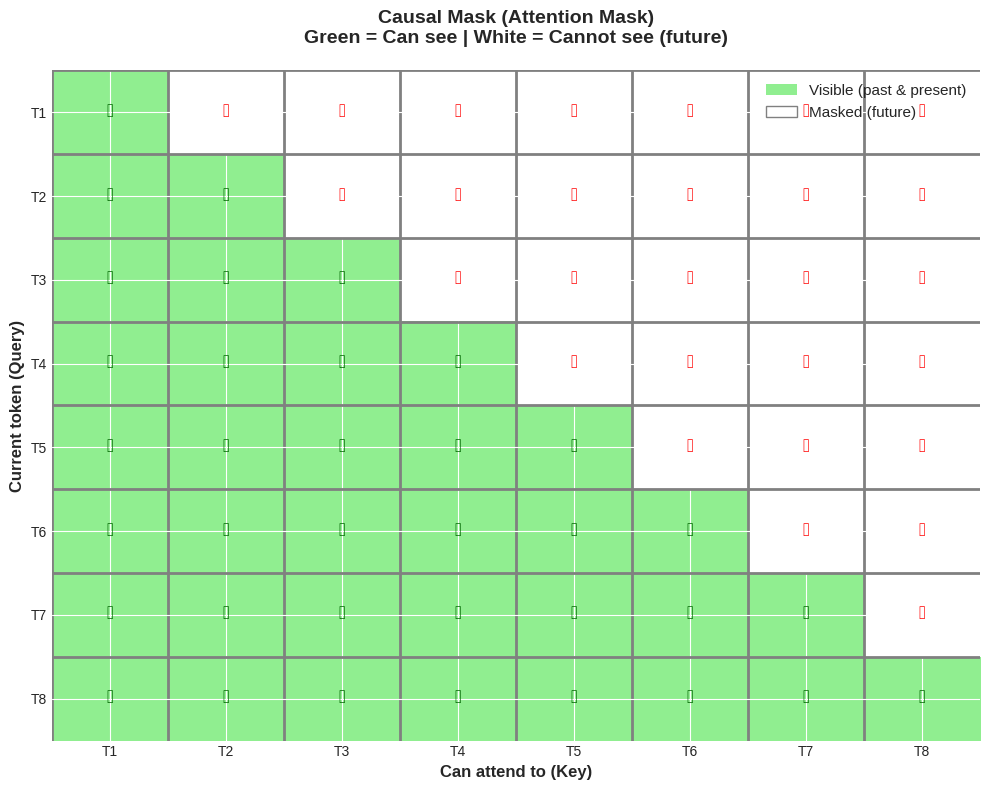


🔒 Causal Mask Explanation:
Token T1 can only see itself (T1)
Token T2 can see T1 and T2
Token T3 can see T1, T2, and T3
...and so on.

This prevents the model from 'cheating' by looking at future tokens!


In [10]:
# Visualization: Causal Mask
fig, ax = plt.subplots(figsize=(10, 8))

seq_len = 8
mask = np.tril(np.ones((seq_len, seq_len)))

# Create custom colormap (white for masked, green for visible)
from matplotlib.colors import ListedColormap
colors = ['white', 'lightgreen']
cmap = ListedColormap(colors)

im = ax.imshow(mask, cmap=cmap, aspect='auto')

# Add grid
ax.set_xticks(np.arange(seq_len))
ax.set_yticks(np.arange(seq_len))
ax.set_xticklabels([f'T{i+1}' for i in range(seq_len)])
ax.set_yticklabels([f'T{i+1}' for i in range(seq_len)])
ax.set_xlabel('Can attend to (Key)', fontsize=12, fontweight='bold')
ax.set_ylabel('Current token (Query)', fontsize=12, fontweight='bold')

# Add grid lines
ax.set_xticks(np.arange(seq_len)-.5, minor=True)
ax.set_yticks(np.arange(seq_len)-.5, minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=2)

# Add annotations
for i in range(seq_len):
    for j in range(seq_len):
        if mask[i, j] == 1:
            ax.text(j, i, '✓', ha='center', va='center', fontsize=14, color='darkgreen', fontweight='bold')
        else:
            ax.text(j, i, '✗', ha='center', va='center', fontsize=14, color='red', fontweight='bold')

ax.set_title('Causal Mask (Attention Mask)\nGreen = Can see | White = Cannot see (future)', 
            fontsize=14, fontweight='bold', pad=20)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='lightgreen', label='Visible (past & present)'),
                  Patch(facecolor='white', edgecolor='gray', label='Masked (future)')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('../visualizations/causal_mask.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🔒 Causal Mask Explanation:")
print("Token T1 can only see itself (T1)")
print("Token T2 can see T1 and T2")
print("Token T3 can see T1, T2, and T3")
print("...and so on.")
print("\nThis prevents the model from 'cheating' by looking at future tokens!")

### 🎭 GPT Architecture Summary

```
Input Text
    ↓
Tokenization (convert to numbers)
    ↓
Token Embeddings (what is each token?)
    ↓
Positional Embeddings (where is each token?)
    ↓
Decoder Block 1 (with causal mask)
    ↓
Decoder Block 2
    ↓
    ...
    ↓
Decoder Block N
    ↓
Output Layer (probability distribution)
    ↓
Next Token Prediction
```

**We'll build this step-by-step in the following notebooks!**

---

## 6. Key Takeaways

### ✅ What We Learned

1. **LLMs are statistical models** that predict the next token based on patterns in training data

2. **Next-token prediction** is the fundamental task:
   - Input: "The cat sat on the"
   - Output: Probability distribution over all possible next words

3. **Transformers replaced RNNs** because:
   - Parallel processing (faster)
   - Better at long-range dependencies
   - Scalable to massive datasets

4. **Encoder vs Decoder**:
   - Encoder: Bidirectional, for understanding (BERT)
   - Decoder: Unidirectional, for generation (GPT)

5. **GPT is Decoder-only** with a causal mask:
   - Can only see past tokens (not future)
   - Optimized for text generation
   - Simpler and more scalable

### 🎯 Next Steps

In the following notebooks, we'll implement:

- **Notebook 1**: Character-level tokenization
- **Notebook 2**: Byte Pair Encoding (BPE)
- **Notebook 3**: Data pipeline and batching
- **Notebook 4**: Token embeddings
- **Notebook 5**: Positional embeddings

By the end, you'll have built the complete preprocessing pipeline for an LLM!

---

## 📚 References

1. **Vizuara AI Lecture Series**: [Building LLMs from Scratch](https://www.youtube.com/playlist?list=PLPTV0NXA_ZSgsLAr8YCgCwhPIJNNtexWu)
   - Lecture 1: Series Introduction
   - Lecture 2: LLM Basics
   - Lecture 3: Pre-training vs Fine-tuning
   - Lecture 4: Transformers

2. **Original Paper**: [Attention Is All You Need](https://arxiv.org/abs/1706.03762) (Vaswani et al., 2017)

3. **GPT-2 Paper**: [Language Models are Unsupervised Multitask Learners](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)

4. **GPT-3 Paper**: [Language Models are Few-Shot Learners](https://arxiv.org/abs/2005.14165)

5. **BERT Paper**: [BERT: Pre-training of Deep Bidirectional Transformers](https://arxiv.org/abs/1810.04805)

6. **The Illustrated Transformer**: [Jay Alammar's Blog](http://jalammar.github.io/illustrated-transformer/)

---

<div style="text-align: center; padding: 20px; background-color: #f0f0f0; border-radius: 10px;">
    <h2>🎉 Congratulations!</h2>
    <p>You now understand the fundamentals of Large Language Models!</p>
    <p><strong>Next:</strong> Notebook 1 - Character-Level Tokenization</p>
</div>